## Analysis of BioProjects/BioSamples

High level analysis of all bioproject/biosample records submitted by public health agencies

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [3]:
all_biosamples = pd.read_csv('representative_bioproject_biosample_flat - representative_bioproject_biosample_flat.csv')
all_biosamples.head(10)

all_bioprojects = pd.read_csv('Ashley_representative_bioproject_biosample_flat - representative_bioproject_biosample_flat.csv')
all_bioprojects.head(10)

/var/folders/4k/j4g2lqw57x957sw_c6pdfy4w0000gn/T/ipykernel_54699/3959103949.py:1: DtypeWarning: Columns (9,10,20,21,22,23,24,25,26,27,28,29,30,31,32,34,35,36,37,38,39,40,41,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,

,RepresentativeSelection.BioSample.id,RepresentativeSelection.BioSample.accession,RepresentativeSelection.BioProject.accession,BioSample.@id,BioSample.@accession,BioProject.Project.ProjectID.ArchiveID.@accession,BioProject.Project.ProjectID.ArchiveID.@id,BioProject.Project.ProjectDescr.Description,BioProject.Project.ProjectDescr.ExternalLink.@label,BioProject.Project.ProjectDescr.ExternalLink.URL,...,Library strategy,Library Source,Library Selection,Library Layout,Umberella Project accession ID,Associated Bioprojects (if its an umberella ),Reference Genome Genebank ID,Reference genome RefSeq ID,Genebank ID,Data Storage Provider
0,5379608,SAMN05379608,PRJNA328792,5379608,SAMN05379608,PRJNA328792,328792,Simultaneous Emergence of multidrug resistant ...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5379608,SAMN05379608,PRJNA722434,5379608,SAMN05379608,PRJNA722434,722434,Global Candida auris genomics surveillance,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13354596,SAMN13354596,PRJNA595978,13354596,SAMN13354596,PRJNA595978,595978,Tracing the evolutionary history and global ex...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,13354597,SAMN13354597,PRJNA595978,13354597,SAMN13354597,PRJNA595978,595978,Tracing the evolutionary history and global ex...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,13354598,SAMN13354598,PRJNA595978,13354598,SAMN13354598,PRJNA595978,595978,Tracing the evolutionary history and global ex...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,13354599,SAMN13354599,PRJNA595978,13354599,SAMN13354599,PRJNA595978,595978,Tracing the evolutionary history and global ex...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,13544843,SAMN13544843,PRJNA595978,13544843,SAMN13544843,PRJNA595978,595978,Tracing the evolutionary history and global ex...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,13613340,SAMN13613340,PRJNA595978,13613340,SAMN13613340,PRJNA595978,595978,Tracing the evolutionary history and global ex...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,13613341,SAMN13613341,PRJNA595978,13613341,SAMN13613341,PRJNA595978,595978,Tracing the evolutionary history and global ex...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,13761842,SAMN13761842,PRJNA595978,13761842,SAMN13761842,PRJNA595978,595978,Tracing the evolutionary history and global ex...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Counts by Species

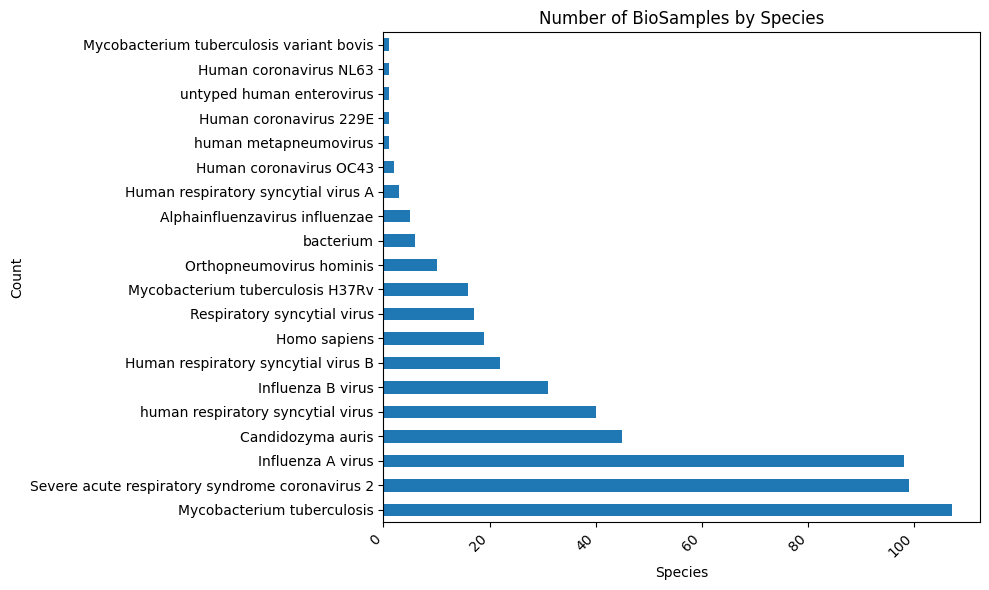

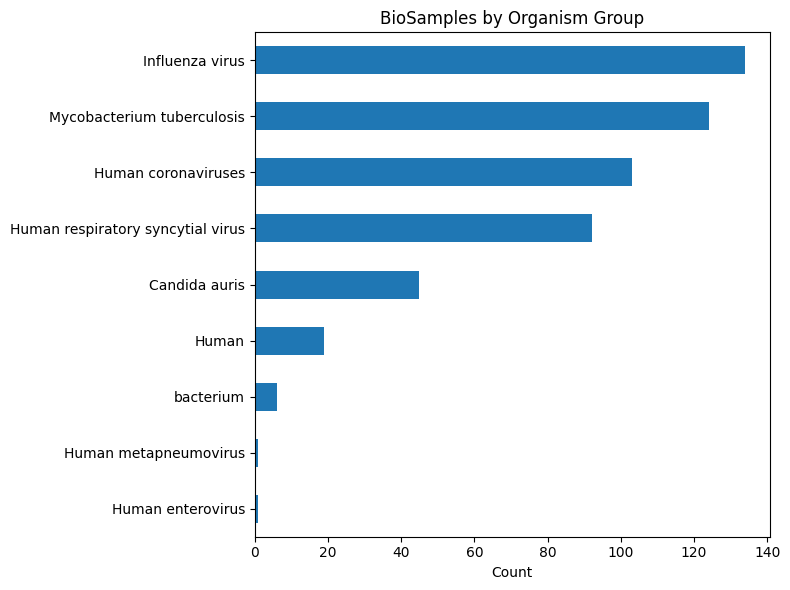

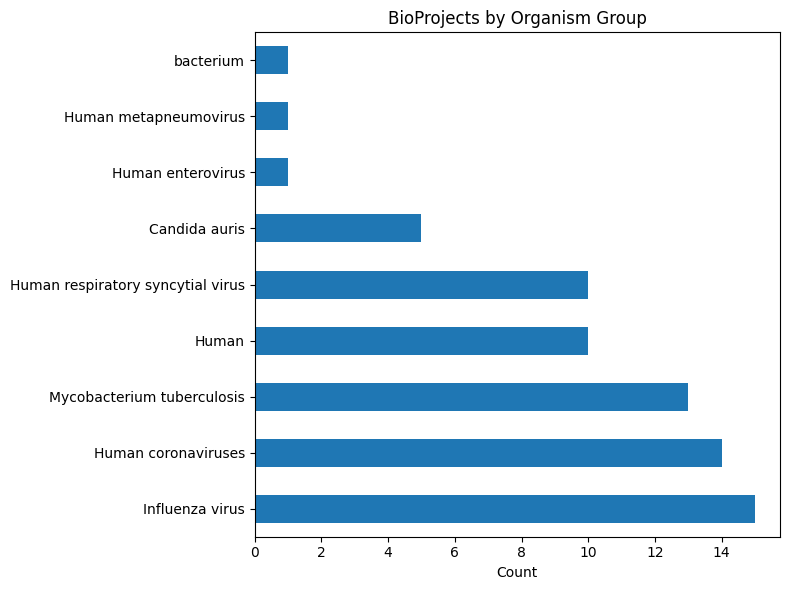

In [4]:
#Counts by species

count_by_species = (
    all_bioprojects['BioSample.Description.Organism.OrganismName']
    .value_counts()
)

count_by_species.plot(kind='barh', figsize=(10, 6))

plt.title('Number of BioSamples by Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

#graph of organism
def group_species(name):
    name = str(name).lower()

    if "tuberculosis" in name:
        return "Mycobacterium tuberculosis"

    elif "influenza a" in name or "alphainfluenzavirus influenzae" in name:
        return "Influenza virus"

    elif "influenza b" in name:
        return "Influenza virus"

    elif "respiratory syncytial" in name or "orthopneumovirus hominis" in name:
        return "Human respiratory syncytial virus"

    elif "candidozyma auris" in name or "candida auris" in name:
        return "Candida auris"

    elif "coronavirus" in name:
        return "Human coronaviruses"

    elif "sars" in name or "severe acute respiratory syndrome coronavirus 2" in name:
        return "SARS-CoV-2"

    elif "metapneumovirus" in name:
        return "Human metapneumovirus"

    elif "enterovirus" in name:
        return "Human enterovirus"

    elif "homo sapiens" in name:
        return "Human"

    else:
        return name

# Apply the grouping
grouped = (
    all_bioprojects['BioSample.Description.Organism.OrganismName']
    .apply(group_species)
    .value_counts()
    .sort_values()
)

# Plot
grouped.plot(kind='barh', figsize=(8,6))

plt.title('BioSamples by Organism Group')
plt.xlabel('Count')
plt.ylabel('')
plt.tight_layout()
plt.show()

#Bioprojects for each organism
bioprojects_per_organism = (
    all_bioprojects
    .groupby(
        all_bioprojects['BioSample.Description.Organism.OrganismName']
        .apply(group_species)
    )['RepresentativeSelection.BioProject.accession']
    .nunique()
    .sort_values(ascending=False)
)

bioprojects_per_organism.plot(kind='barh', figsize=(8,6))

plt.title('BioProjects by Organism Group')
plt.xlabel('Count')
plt.ylabel('')
plt.tight_layout()
plt.show()

## submission by agency (owner name???)

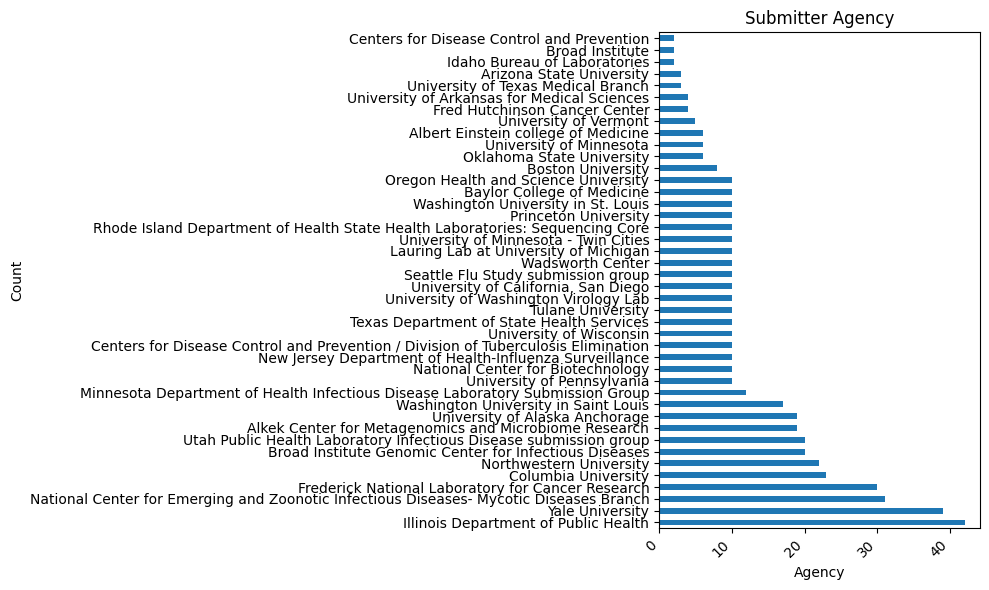

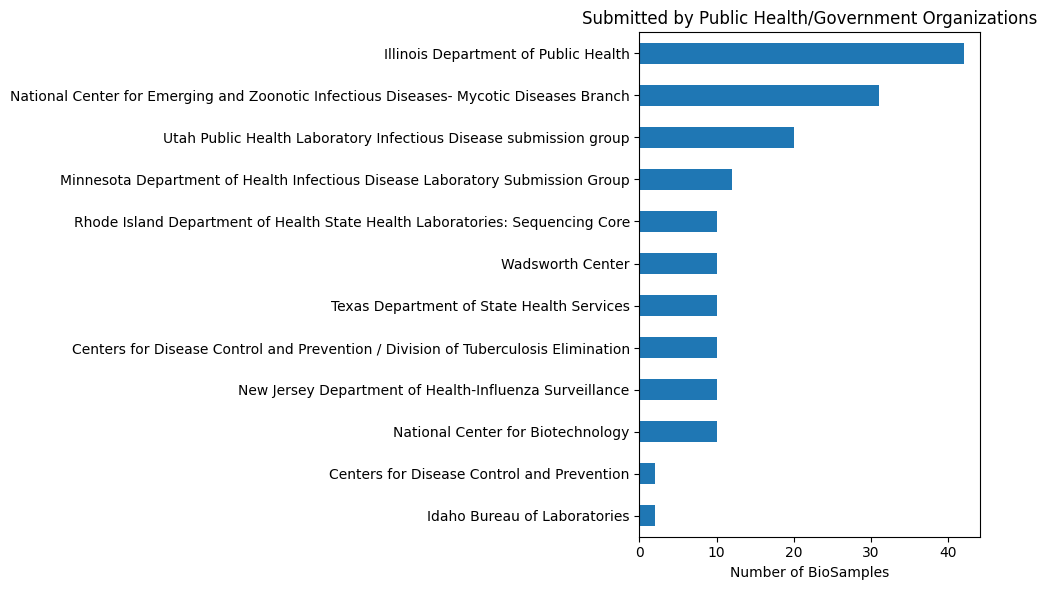

In [5]:
#submission by agency (owner name???)

agency = all_bioprojects.value_counts('BioSample.Owner.Name')
agency

agency = (
    all_bioprojects['BioSample.Owner.Name']
    .value_counts()
)

agency.plot(kind='barh', figsize=(10, 6))

plt.title('Submitter Agency')
plt.xlabel('Agency')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

#public health only
owners = (
    all_bioprojects['BioSample.Owner.Name']
    .value_counts()
)

# Keep only public health/government organizations
gov_owners = owners[
    owners.index.str.contains(
        r'Public Health|Department of Health|Centers for Disease Control|CDC|National Center|State Health|Bureau of Laboratories|Wadsworth',
        case=False,
        regex=True
    )
]

gov_owners = gov_owners.sort_values()

gov_owners.plot(kind='barh', figsize=(10, 6))

plt.title('Submitted by Public Health/Government Organizations')
plt.xlabel('Number of BioSamples')
plt.ylabel('')
plt.tight_layout()
plt.show()

## completness

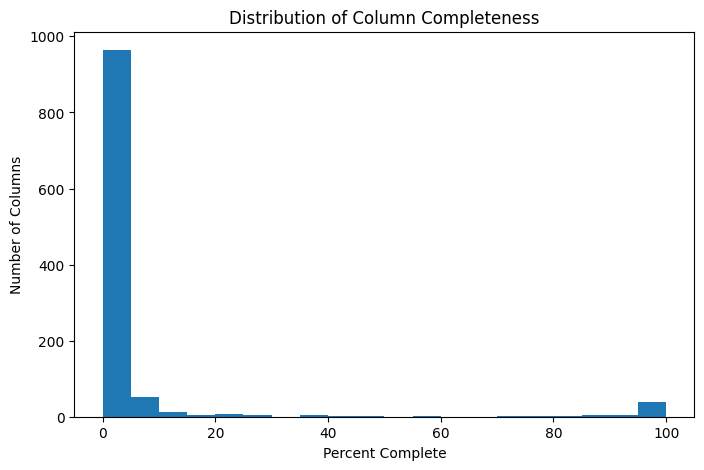

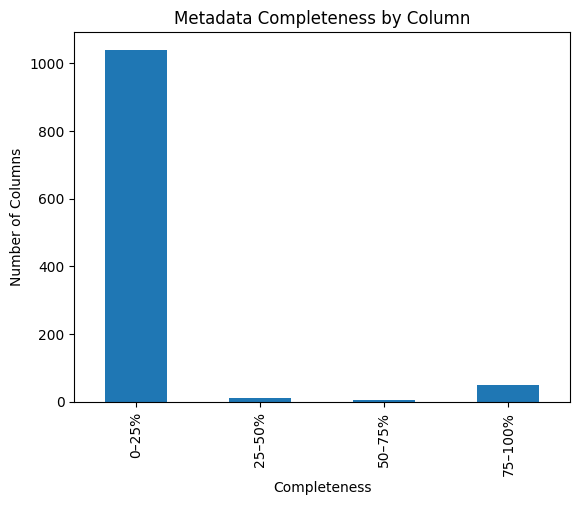

In [6]:
#completness

completeness = (
    all_bioprojects.notna().mean() * 100
).sort_values(ascending=False)

missingness = 100 - completeness

#percent completeness for every column
missingness

#breakdown of number of columns by % of completeness
plt.figure(figsize=(8,5))
plt.hist(completeness, bins=20)
plt.xlabel("Percent Complete")
plt.ylabel("Number of Columns")
plt.title("Distribution of Column Completeness")
plt.show()

#summary of completness
summary = pd.cut(
    completeness,
    bins=[0,25,50,75,100],
    labels=["0–25%","25–50%","50–75%","75–100%"],
    include_lowest=True
).value_counts().sort_index()

summary.plot(kind="bar")
plt.ylabel("Number of Columns")
plt.xlabel("Completeness")
plt.title("Metadata Completeness by Column")
plt.show()

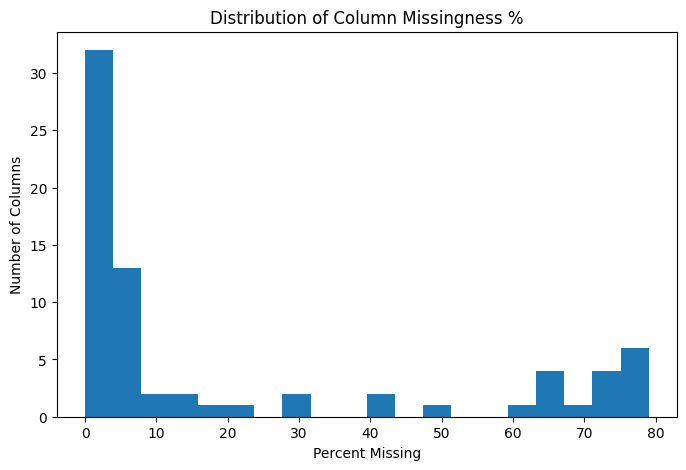

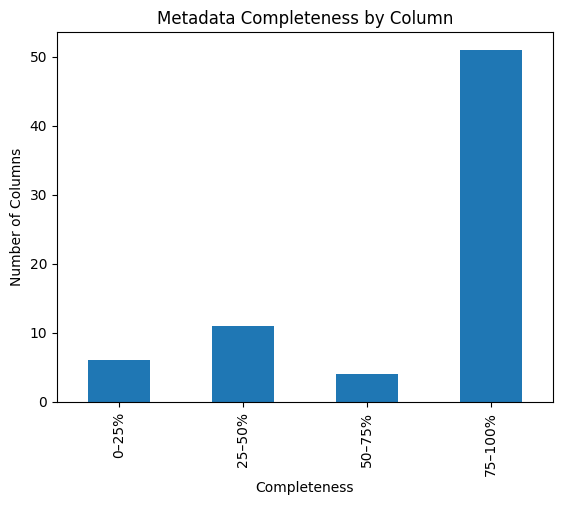

Original columns: 1106
Remaining columns: 72
Dropped columns: 1034
Attributes kept:  RepresentativeSelection.BioSample.id                0.000000
BioSample.@access                                   0.000000
BioSample.Status.@status                            0.000000
BioSample.@publication_date                         0.000000
BioSample.@submission_date                          0.000000
                                                     ...    
BioProject.Project.ProjectDescr.Grant.PI.@auth     76.571429
BioProject.Project.ProjectDescr.Grant.PI.@affil    76.571429
BioProject.Project.ProjectDescr.Grant.PI.Last      76.571429
BioProject.Project.ProjectDescr.Grant.PI.Given     76.571429
BioSample.Owner.Contacts.Contact.Name.Middle       79.047619
Length: 72, dtype: float64


In [7]:
#drop columns that are over 80% missing

#Percentage of missing values in each column
missing_pct = all_bioprojects.isna().mean() * 100

#Keep columns with 80% or less missing
all_bioprojects_filtered = all_bioprojects.loc[:, missing_pct <= 80]
all_bioprojects_filtered

completeness = (
    all_bioprojects_filtered.notna().mean() * 100
).sort_values(ascending=False)

missingness = 100 - completeness

#breakdown of number of columns by % of completeness
plt.figure(figsize=(8,5))
plt.hist(missingness, bins=20)
plt.xlabel("Percent Missing")
plt.ylabel("Number of Columns")
plt.title("Distribution of Column Missingness %")
plt.show()

#summary of completness
summary = pd.cut(
    completeness,
    bins=[0,25,50,75,100],
    labels=["0–25%","25–50%","50–75%","75–100%"],
    include_lowest=True
).value_counts().sort_index()

summary.plot(kind="bar")
plt.ylabel("Number of Columns")
plt.xlabel("Completeness")
plt.title("Metadata Completeness by Column")
plt.show()

print(f"Original columns: {all_bioprojects.shape[1]}")
print(f"Remaining columns: {all_bioprojects_filtered.shape[1]}")
print(f"Dropped columns: {all_bioprojects.shape[1] - all_bioprojects_filtered.shape[1]}")

#kept columns + missingness %
kept_columns = missing_pct[missing_pct <= 80].sort_values()
print("Attributes kept: ", kept_columns)

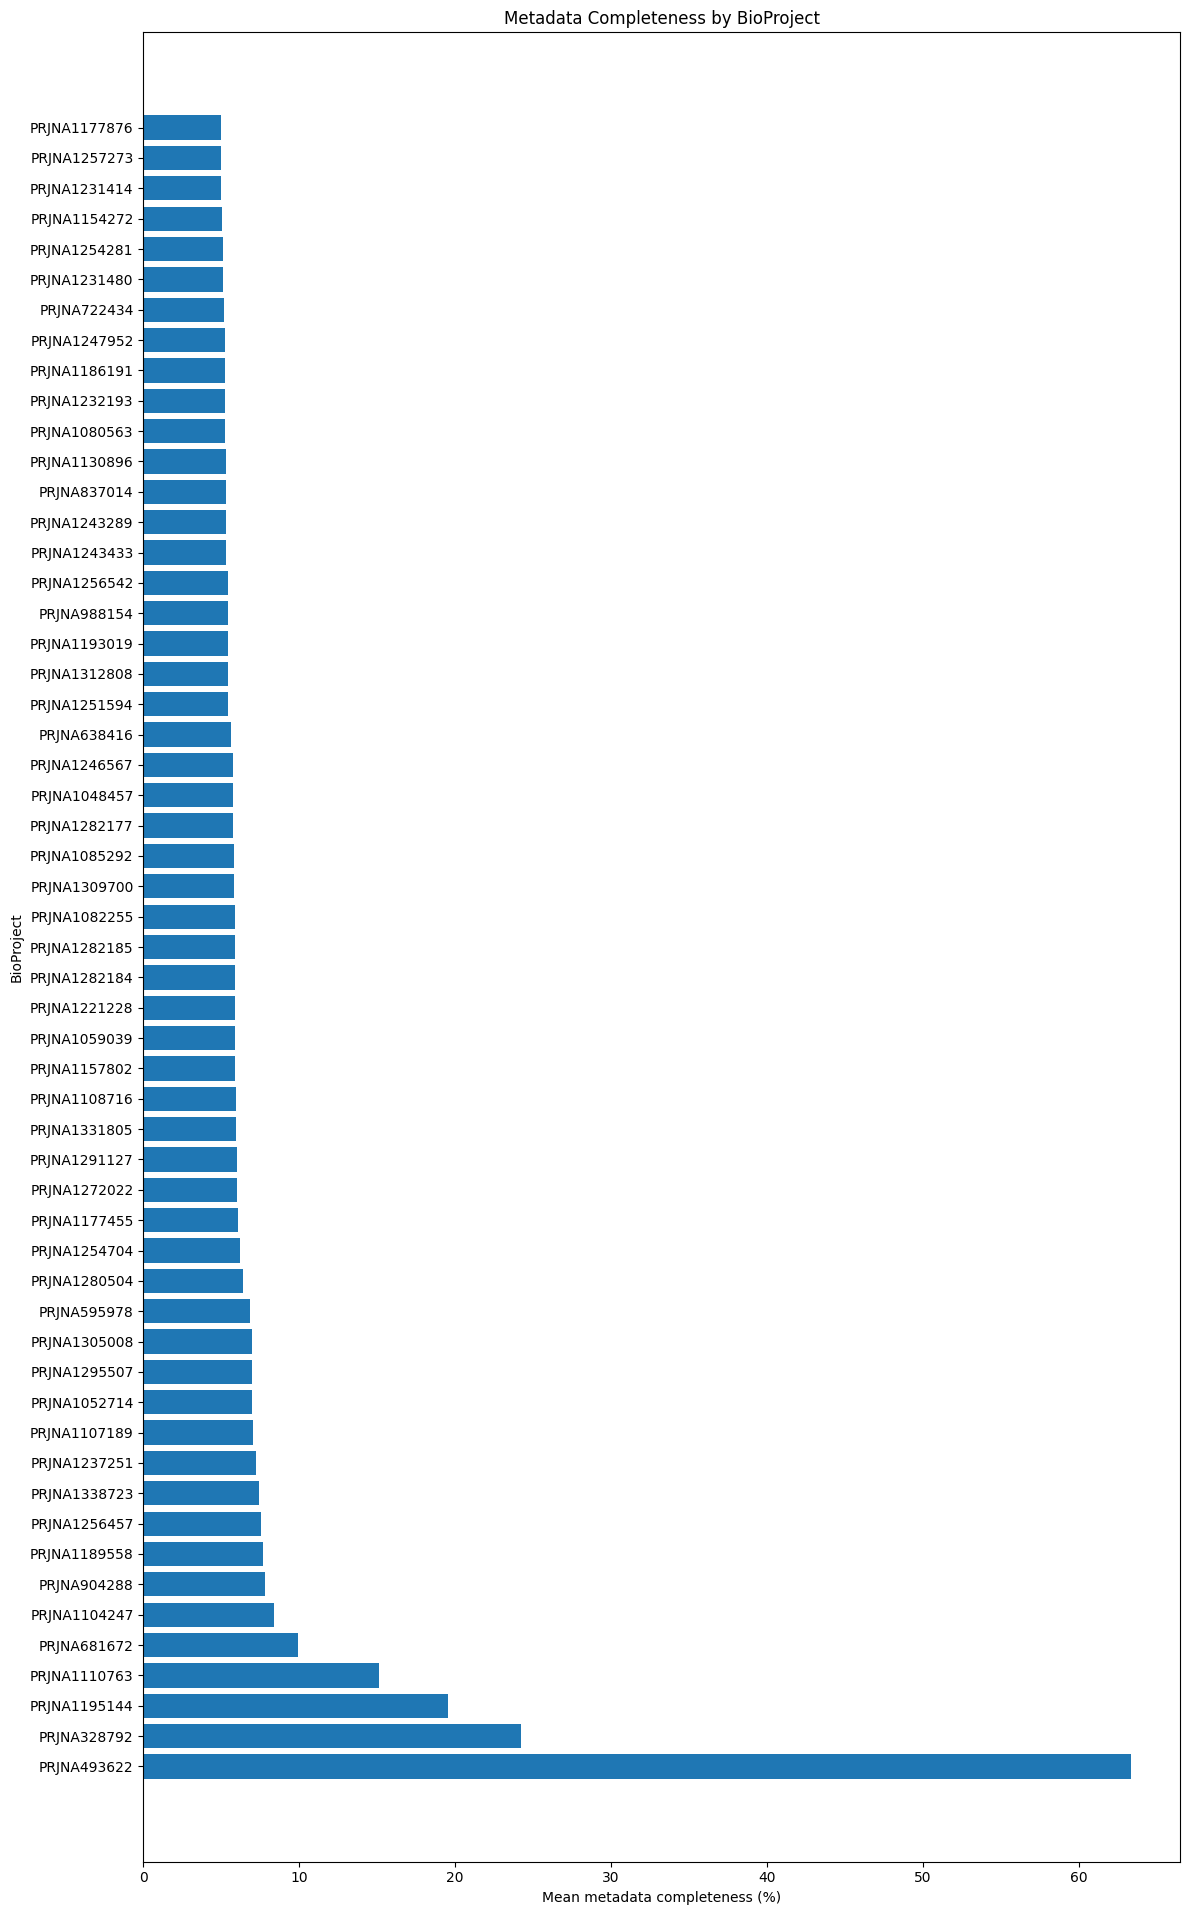

In [39]:
bioproject_col = 'RepresentativeSelection.BioProject.accession'

# Optional: define values that should count as missing
missing_strings = {
    "", "na", "n/a", "nan", "none", "null",
    "unknown", "not collected", "not provided"
}

df = all_bioprojects.copy()
df = df.replace(
    to_replace=list(missing_strings),
    value=np.nan
)


metadata_cols = [col for col in df.columns if col != bioproject_col]
df["row_completeness"] = df[metadata_cols].notna().mean(axis=1) * 100
df["row_missingness"] = 100 - df["row_completeness"]

#average completeness across records in each BioProject
bioproject_completeness = (
    df.groupby(bioproject_col)
      .agg(
          n_records=("row_completeness", "size"),
          mean_completeness_pct=("row_completeness", "mean"),
          median_completeness_pct=("row_completeness", "median"),
          mean_missingness_pct=("row_missingness", "mean")
      )
      .reset_index()
      .sort_values("mean_completeness_pct", ascending=False)
)

bioproject_completeness

plt.figure(figsize=(12, max(6, 0.35 * len(bioproject_completeness))))
plt.barh(bioproject_completeness[bioproject_col].astype(str), bioproject_completeness["mean_completeness_pct"])
plt.xlabel("Mean metadata completeness (%)")
plt.ylabel("BioProject")
plt.title("Metadata Completeness by BioProject")
plt.tight_layout()

plt.savefig("bioproject_completeness_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## Not collected / Unknown

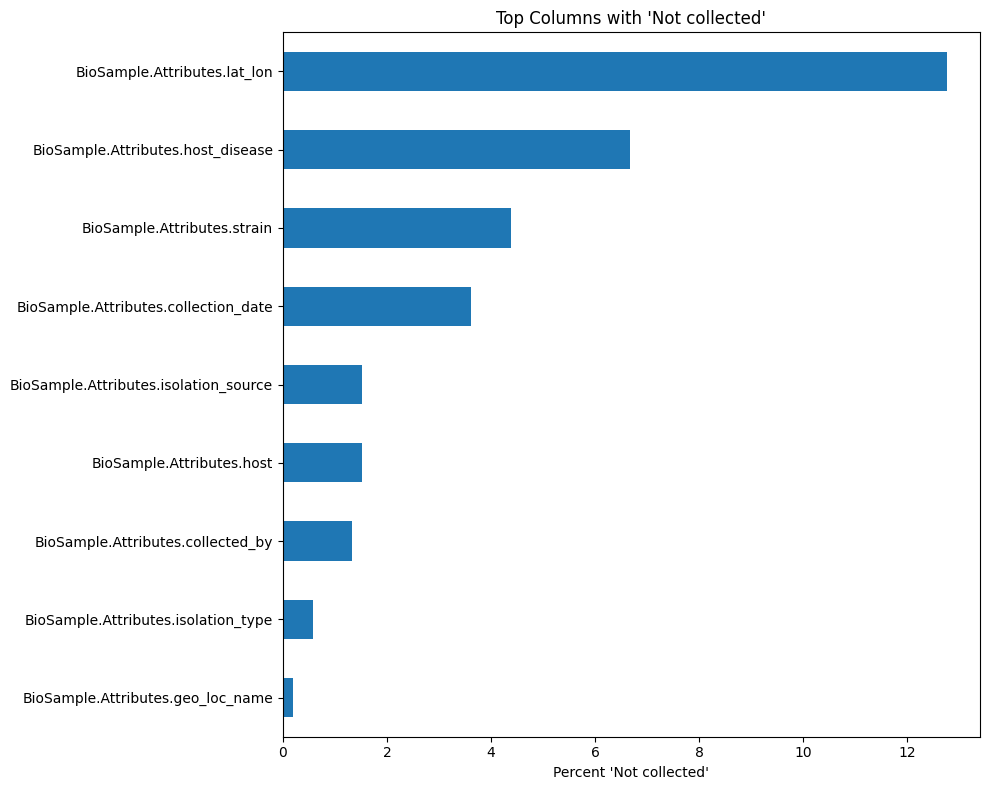

BioSample.Attributes.isolation_source                                                             0.380952
BioProject.Project.ProjectDescr.Publication.StructuredCitation.AuthorSet.Author[26].Name.Last     0.000000
BioProject.Project.ProjectDescr.Publication.StructuredCitation.AuthorSet.Author[28].Name.Last     0.000000
BioProject.Project.ProjectDescr.Publication.StructuredCitation.AuthorSet.Author[28].Name.First    0.000000
BioProject.Project.ProjectDescr.Publication.StructuredCitation.AuthorSet.Author[28].Consortium    0.000000
                                                                                                    ...   
BioProject.Project.ProjectDescr.LocusTagPrefix[248].@biosample_id                                 0.000000
BioProject.Project.ProjectDescr.LocusTagPrefix[249]                                               0.000000
BioProject.Project.ProjectDescr.LocusTagPrefix[249].@biosample_id                                 0.000000
BioProject.Project.ProjectDescr.Locus

In [8]:
#Not collected / Unknown

#Not collected
not_collected = (
    all_bioprojects
    .astype(str)
    .apply(lambda col: col.str.lower().eq("not collected").mean() * 100)
    .sort_values(ascending=False)
)

top = not_collected.head(9).sort_values()

plt.figure(figsize=(10, 8))
top.plot(kind="barh")

plt.xlabel("Percent 'Not collected'")
plt.title("Top Columns with 'Not collected'")
plt.tight_layout()
plt.show()


#Unknown
unknown = (
    all_bioprojects
    .astype(str)
    .apply(lambda col: col.str.lower().eq("unknown").mean() * 100)
    .sort_values(ascending=False)
)
unknown

## Number of Bioprojects/Biosamples

In [9]:
#Number of Bioprojects/Biosamples

#Bioproject
bioprojects = all_bioprojects['RepresentativeSelection.BioProject.accession'].nunique()
print("Number of Unique bioprojects: ", bioprojects)

#Biosample
biosamples = all_bioprojects['RepresentativeSelection.BioSample.accession'].nunique()
print("Number of Unique biosamples: ", biosamples)

#Biosamples per bioproject
biosamples_per_bioproject = (
    all_bioprojects['RepresentativeSelection.BioProject.accession']
    .value_counts()
    .rename_axis('BioProject')
    .reset_index(name='Number of BioSamples')
)
print("Number of biosamples per bioproject: ", biosamples_per_bioproject)

Number of Unique bioprojects:  55
Number of Unique biosamples:  473
Number of biosamples per bioproject:        BioProject  Number of BioSamples
0   PRJNA1291127                    14
1   PRJNA1052714                    12
2   PRJNA1048457                    12
3    PRJNA988154                    11
4   PRJNA1110763                    11
5   PRJNA1107189                    11
6   PRJNA1130896                    11
7   PRJNA1232193                    11
8    PRJNA722434                    11
9   PRJNA1177876                    11
10  PRJNA1177455                    11
11  PRJNA1059039                    11
12  PRJNA1082255                    11
13  PRJNA1221228                    11
14  PRJNA1231414                    11
15  PRJNA1280504                    11
16  PRJNA1237251                    11
17  PRJNA1257273                    11
18  PRJNA1108716                    11
19  PRJNA1104247                    11
20  PRJNA1256542                    11
21  PRJNA1282185                    

## Collection date

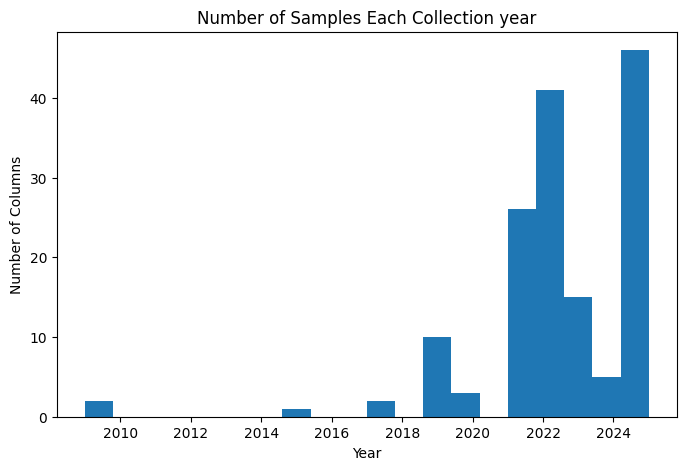

In [10]:
#Collection date

date = all_bioprojects.value_counts("BioSample.Attributes.collection_date")
date

date = pd.to_datetime(
    all_bioprojects['BioSample.Attributes.collection_date'],
    errors='coerce'
)

years = date.dt.year

#breakdown of number of columns by % of completeness
plt.figure(figsize=(8,5))
plt.hist(years, bins=20)
plt.xlabel("Year")
plt.ylabel("Number of Columns")
plt.title("Number of Samples Each Collection year")
plt.show()

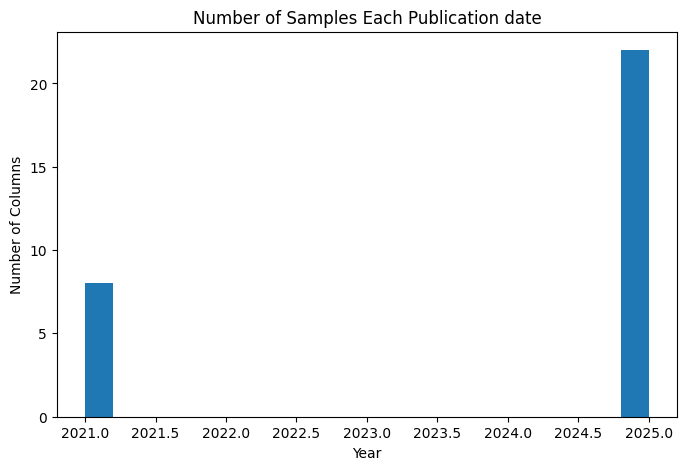

In [23]:
#Publication date

date_pub = all_bioprojects.value_counts("BioProject.Project.ProjectDescr.Publication.@date")
date_pub

date_pub = pd.to_datetime(
    all_bioprojects['BioProject.Project.ProjectDescr.Publication.@date'],
    errors='coerce'
)

years_pub = date_pub.dt.year

#breakdown of number of columns by % of completeness
plt.figure(figsize=(8,5))
plt.hist(years_pub, bins=20)
plt.xlabel("Year")
plt.ylabel("Number of Columns")
plt.title("Number of Samples Each Publication date")
plt.show()

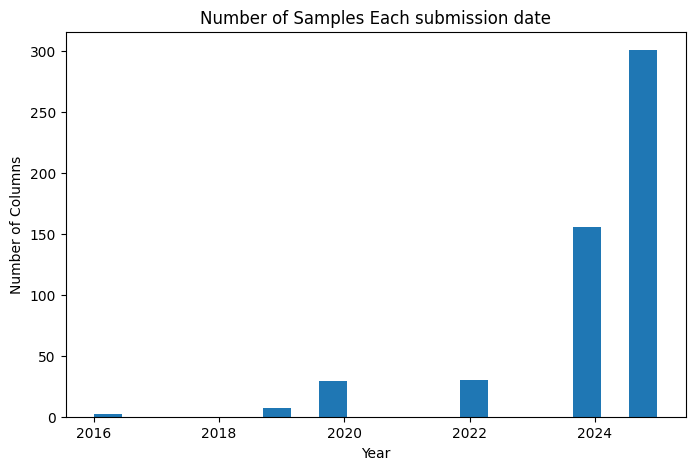

In [24]:
#Submission date date

date_sub = all_bioprojects.value_counts("BioSample.@submission_date")
date_sub

date_sub = pd.to_datetime(
    all_bioprojects['BioSample.@submission_date'],
    errors='coerce'
)

years_sub = date_sub.dt.year

#breakdown of number of columns by % of completeness
plt.figure(figsize=(8,5))
plt.hist(years_sub, bins=20)
plt.xlabel("Year")
plt.ylabel("Number of Columns")
plt.title("Number of Samples Each submission date")
plt.show()

## Temploral Information

In [ ]:
pub = BioSample.@publication_date
sub = BioSample.@submission_date
col = BioSample.Attributes.collection_date
pub2 = BioProject.Project.ProjectDescr.Publication[2].@date
pub1 = BioProject.Project.ProjectDescr.Publication[1].@date

Median lag: 1027 days
Mean lag: 1055.0 days


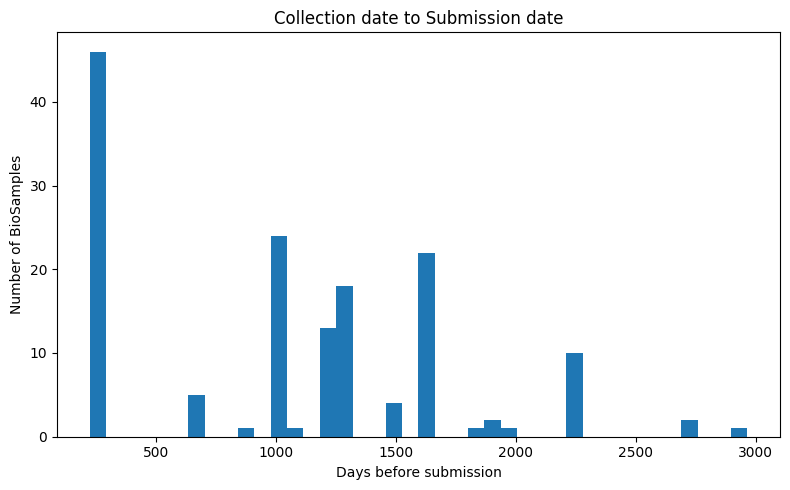

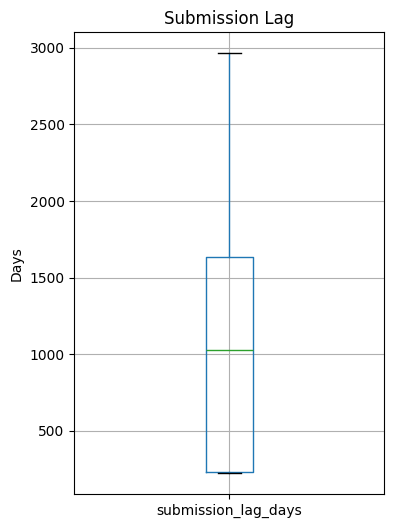

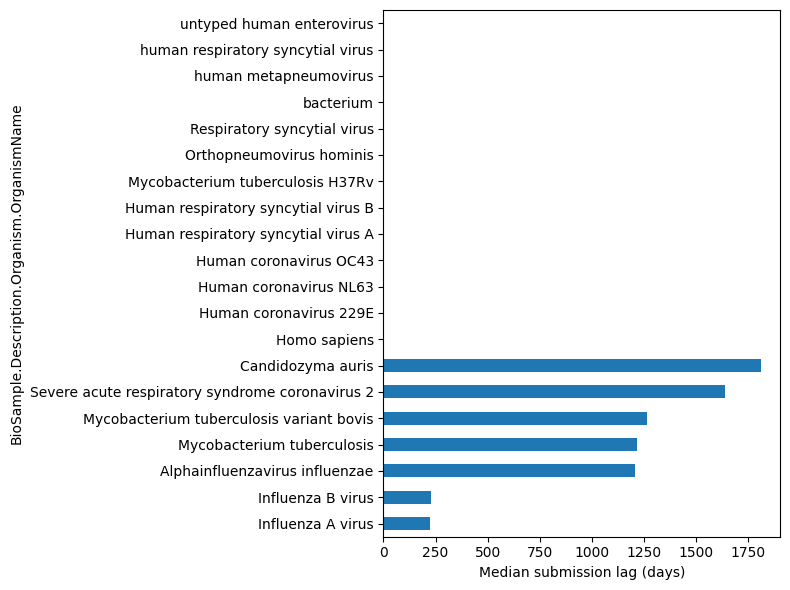

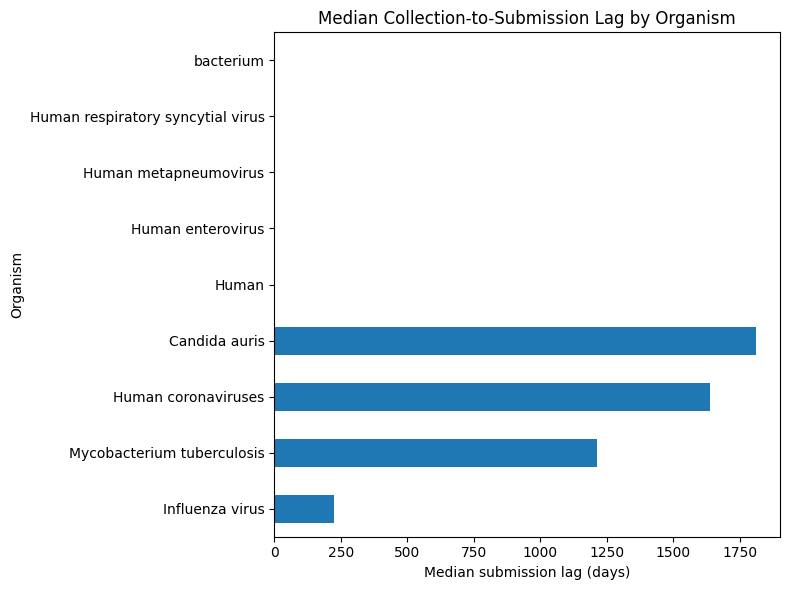

In [20]:
#collection to submission time

#dates of interest
all_bioprojects["collection_date"] = pd.to_datetime(
    all_bioprojects["BioSample.Attributes.collection_date"],
    errors="coerce"
)

all_bioprojects["submission_date"] = pd.to_datetime(
    all_bioprojects["BioSample.@submission_date"],
    errors="coerce"
)

#lag time
all_bioprojects["submission_lag_days"] = (
    all_bioprojects["submission_date"]
    - all_bioprojects["collection_date"]
).dt.days

#summary
all_bioprojects["submission_lag_days"].describe()

median = all_bioprojects["submission_lag_days"].median()
mean = all_bioprojects["submission_lag_days"].mean()

print(f"Median lag: {median:.0f} days")
print(f"Mean lag: {mean:.1f} days")


plt.figure(figsize=(8,5))
all_bioprojects["submission_lag_days"].plot(
    kind="hist",
    bins=40
)

plt.xlabel("Days before submission")
plt.ylabel("Number of BioSamples")
plt.title("Collection date to Submission date")
plt.tight_layout()
plt.show()

#boxplot
plt.figure(figsize=(4,6))
all_bioprojects.boxplot(column="submission_lag_days")
plt.ylabel("Days")
plt.title("Submission Lag")
plt.show()

#by organism
lag_by_organism = (
    all_bioprojects
    .groupby("BioSample.Description.Organism.OrganismName")[
        "submission_lag_days"
    ]
    .median()
    .sort_values()
)

lag_by_organism.plot(
    kind="barh",
    figsize=(8,6)
)

plt.xlabel("Median submission lag (days)")
plt.tight_layout()
plt.show()

#group by organism
all_bioprojects["Organism_Group"] = (
    all_bioprojects["BioSample.Description.Organism.OrganismName"]
    .apply(group_species)
)

# Calculate median lag by grouped organism
lag_by_organism = (
    all_bioprojects
    .groupby("Organism_Group")["submission_lag_days"]
    .median()
    .sort_values()
)

# Plot
lag_by_organism.plot(
    kind="barh",
    figsize=(8, 6)
)

plt.xlabel("Median submission lag (days)")
plt.ylabel("Organism")
plt.title("Median Collection-to-Submission Lag by Organism")
plt.tight_layout()
plt.show()

## Metadata richness

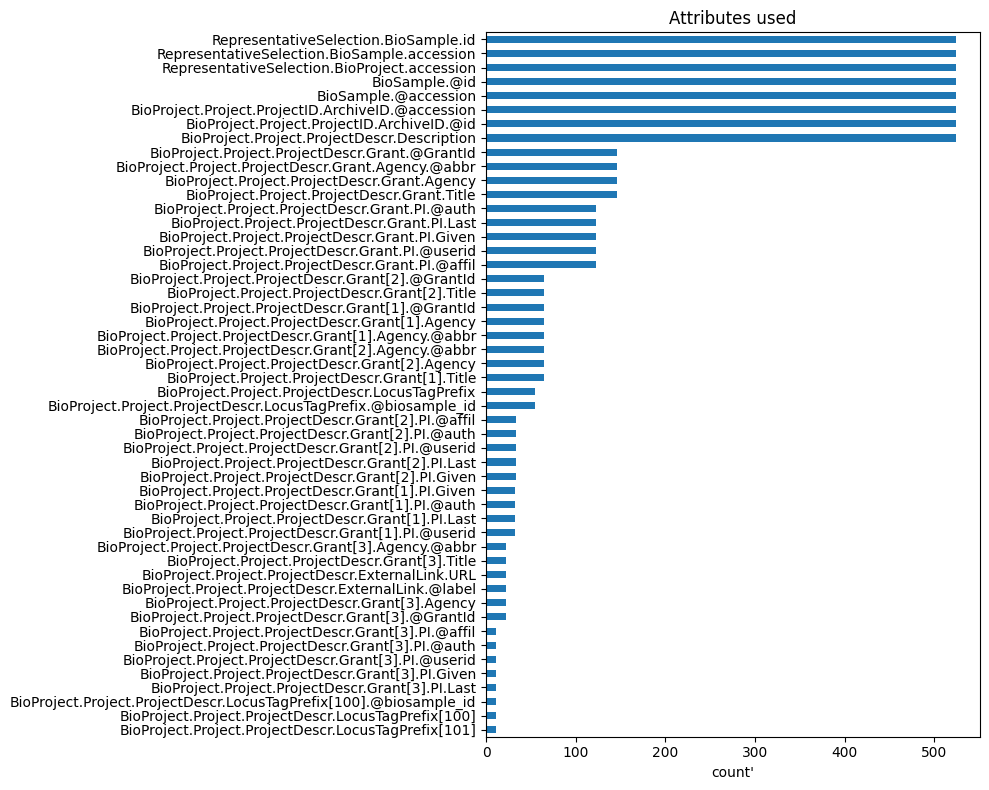

In [27]:
all_bioprojects_copy = all_bioprojects.copy()

attribute_use = (
    all_bioprojects_copy
    .replace("Not collected", pd.NA)
    .replace("Unknown", pd.NA)
    .notna()
    .sum()
)

plt.figure(figsize=(10, 8))
top = attribute_use.head(50).sort_values()
top.plot(kind="barh")

plt.xlabel("count'")
plt.title("Attributes used")
plt.tight_layout()
plt.show()

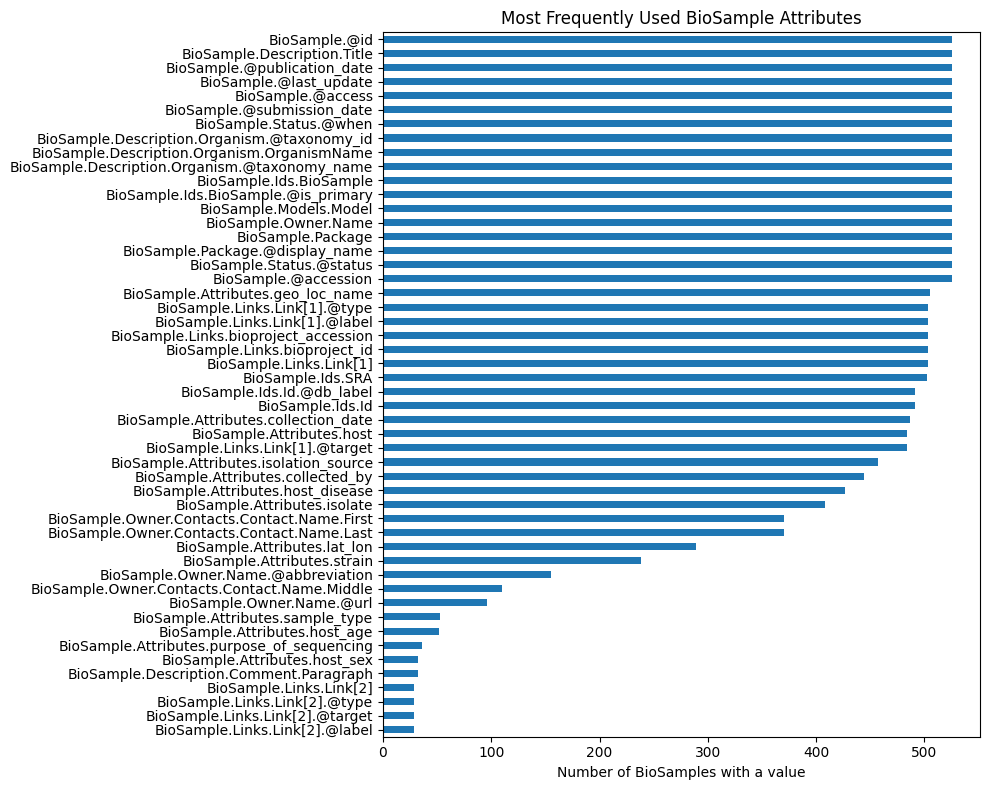

In [31]:
biosample_cols = all_bioprojects_copy.loc[
    :,
    all_bioprojects_copy.columns.str.startswith("BioSample")
]

attribute_use = (
    biosample_cols
    .replace("Not collected", pd.NA)
    .replace("Unknown", pd.NA)
    .notna()
    .sum()
    .sort_values(ascending=False)
)

top = attribute_use.head(50).sort_values()

plt.figure(figsize=(10, 8))
top.plot(kind="barh")

plt.xlabel("Number of BioSamples with a value")
plt.title("Most Frequently Used BioSample Attributes")
plt.tight_layout()
plt.show()

## Consistency

In [44]:
#measuring consistency accross fields
#This is hard because we do expect some inconsistencies due to the different organisms so Im trying to focus on the areas that could easly be the same format throughout.

df = all_bioprojects.copy()


consistency_fields = [
    "BioSample.Attributes.host",
    "Country",
    "BioSample.Attributes.isolation_source",
    "BioSample.Attributes.diagnosis",
    "BioSample.Attributes.geo_loc_name",
    "BioSample.Attributes.host_disease",
    "BioSample.Attributes.isolation_type",
    "BioSample.Description.Organism.@taxonomy_name",
    "BioSample.Description.Organism.OrganismName",
    "BioSample.Attributes.collection_date",
    "BioSample.Attributes.collected_by"
    
]

#clean/normalize
missing_strings = {
    "", "na", "n/a", "nan", "none", "null",
    "unknown", "not collected", "not provided"
}

def is_missing(x):
    if pd.isna(x):
        return True
    if isinstance(x, str) and x.strip().lower() in missing_strings:
        return True
    return False

def normalize_text(x):
    """
    Normalize text for consistency checking:
    - Unicode normalize
    - strip whitespace
    - collapse repeated spaces
    - lowercase
    """
    if is_missing(x):
        return np.nan
    x = str(x)
    x = unicodedata.normalize("NFKC", x)
    x = x.strip()
    x = re.sub(r"\s+", " ", x)
    x = x.lower()
    return x


field_value_tables = {}

for col in consistency_fields:
    if col not in df.columns:
        print(f"Skipping missing column: {col}")
        continue

    temp = df[[col]].copy()
    temp[col] = temp[col].apply(lambda x: np.nan if is_missing(x) else x)

    #Raw value counts
    raw_counts = (
        temp[col]
        .astype("string")
        .fillna("<<MISSING>>")
        .value_counts(dropna=False)
        .reset_index()
    )
    raw_counts.columns = ["value", "count"]

    #Normalized value counts
    temp["normalized"] = temp[col].apply(normalize_text)
    norm_counts = (
        temp["normalized"]
        .astype("string")
        .fillna("<<MISSING>>")
        .value_counts(dropna=False)
        .reset_index()
    )
    norm_counts.columns = ["normalized_value", "count"]

    field_value_tables[col] = {
        "raw_counts": raw_counts,
        "normalized_counts": norm_counts
    }


    print(f"\n=== {col} ===")
    print(raw_counts.head(10).to_string(index=False))


##### I dont find the below to be very helpful because we expect to see lots of inconsistencies and I feel that these dont paint a good picture but I decided to leave
    #them in just incase

# #Most inconsistent
# inconsistency_summary = []

# for col in consistency_fields:
#     if col not in df.columns:
#         continue

#     temp = df[[col]].copy()
#     temp = temp[~temp[col].apply(is_missing)].copy()

#     temp["raw"] = temp[col].astype(str).str.strip()
#     temp["normalized"] = temp["raw"].apply(normalize_text)

#     n_records = len(temp)
#     n_unique_raw = temp["raw"].nunique(dropna=True)
#     n_unique_normalized = temp["normalized"].nunique(dropna=True)

#     inconsistency_summary.append({
#         "field": col,
#         "n_records": n_records,
#         "n_unique_raw_values": n_unique_raw,
#         "n_unique_normalized_values": n_unique_normalized,
#         "redundant_spellings": n_unique_raw - n_unique_normalized,
#         "consistency_ratio": (
#             n_unique_normalized / n_unique_raw if n_unique_raw > 0 else np.nan
#         )
#     })

# inconsistency_df = pd.DataFrame(inconsistency_summary)

# #number of redundant spellings, then unique raw values
# inconsistency_df = inconsistency_df.sort_values(
#     ["redundant_spellings", "n_unique_raw_values"],
#     ascending=False
# )

# print("\n=== Top inconsistent fields ===")
# print(inconsistency_df.to_string(index=False))

# inconsistency_df.to_csv("top_inconsistent_fields.csv", index=False)

# #bar lot showing attributes with greatest inconsistencies
# plot_df = inconsistency_df.sort_values("n_unique_raw_values", ascending=True)

# plt.figure(figsize=(10, 6))
# plt.barh(plot_df["field"], plot_df["n_unique_raw_values"])
# plt.xlabel("Number of unique raw values")
# plt.ylabel("Field")
# plt.title("Fields with the Most Unique Spellings / Representations")
# plt.tight_layout()
# plt.savefig("inconsistent_fields_barplot.png", dpi=300, bbox_inches="tight")
# plt.show()


=== BioSample.Attributes.host ===
       value  count
Homo sapiens    484
 <<MISSING>>     41
Skipping missing column: Country

=== BioSample.Attributes.isolation_source ===
              value  count
         nasal swab    122
        <<MISSING>>     69
             sputum     30
           clinical     30
        Nasal swabs     29
        nasopharynx     22
nasopharyngeal swab     22
              human     20
culture from sputum     19
         Nasal wash     17

=== BioSample.Attributes.diagnosis ===
      value  count
<<MISSING>>    506
   COVID-19     19

=== BioSample.Attributes.geo_loc_name ===
                      value  count
                        USA     48
              USA: Illinois     42
                 USA: Texas     29
           USA:Philadelphia     27
               South Africa     23
                <<MISSING>>     20
         USA: Massachusetts     20
                USA: Alaska     19
USA: Minnesota, Minneapolis     16
            USA: Washington     14

==